In [ ]:
!pip install scikit-fuzzy

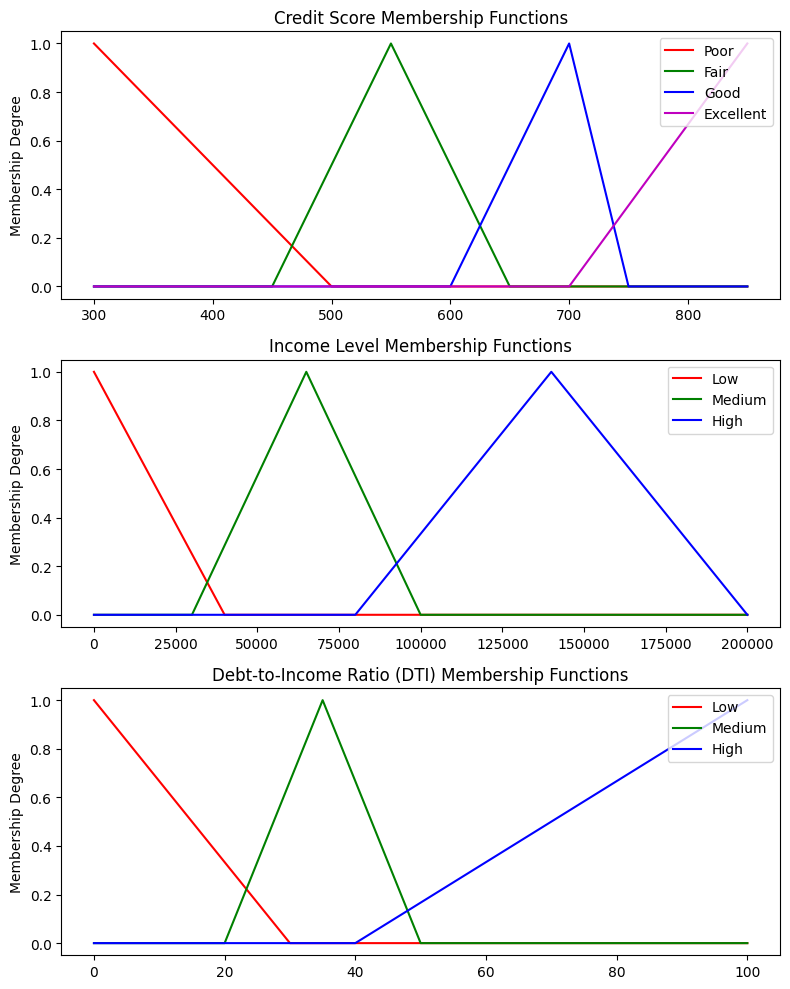

In [ ]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

# Set up the figure
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 10))

# ---------------------------------------------------------------------
# 1. Credit Score Membership Functions
# ---------------------------------------------------------------------
credit_score = np.arange(300, 851, 1)

# Define fuzzy sets
poor = fuzz.trimf(credit_score, [300, 300, 500])
fair = fuzz.trimf(credit_score, [450, 550, 650])
good = fuzz.trimf(credit_score, [600, 700, 750])
excellent = fuzz.trimf(credit_score, [700, 850, 850])

# Plot
ax1.plot(credit_score, poor, 'r', linewidth=1.5, label='Poor')
ax1.plot(credit_score, fair, 'g', linewidth=1.5, label='Fair')
ax1.plot(credit_score, good, 'b', linewidth=1.5, label='Good')
ax1.plot(credit_score, excellent, 'm', linewidth=1.5, label='Excellent')
ax1.set_title('Credit Score Membership Functions')
ax1.set_ylabel('Membership Degree')
ax1.legend(loc='upper right')

# ---------------------------------------------------------------------
# 2. Income Membership Functions
# ---------------------------------------------------------------------
income = np.arange(0, 200001, 1000)

low = fuzz.trimf(income, [0, 0, 40000])
medium = fuzz.trimf(income, [30000, 65000, 100000])
high = fuzz.trimf(income, [80000, 140000, 200000])

ax2.plot(income, low, 'r', linewidth=1.5, label='Low')
ax2.plot(income, medium, 'g', linewidth=1.5, label='Medium')
ax2.plot(income, high, 'b', linewidth=1.5, label='High')
ax2.set_title('Income Level Membership Functions')
ax2.set_ylabel('Membership Degree')
ax2.legend(loc='upper right')

# ---------------------------------------------------------------------
# 3. Debt-to-Income (DTI) Membership Functions
# ---------------------------------------------------------------------
dti = np.arange(0, 101, 1)

low_dti = fuzz.trimf(dti, [0, 0, 30])
medium_dti = fuzz.trimf(dti, [20, 35, 50])
high_dti = fuzz.trimf(dti, [40, 100, 100])

ax3.plot(dti, low_dti, 'r', linewidth=1.5, label='Low')
ax3.plot(dti, medium_dti, 'g', linewidth=1.5, label='Medium')
ax3.plot(dti, high_dti, 'b', linewidth=1.5, label='High')
ax3.set_title('Debt-to-Income Ratio (DTI) Membership Functions')
ax3.set_ylabel('Membership Degree')
ax3.legend(loc='upper right')

# Adjust layout and display
plt.tight_layout()
plt.show()

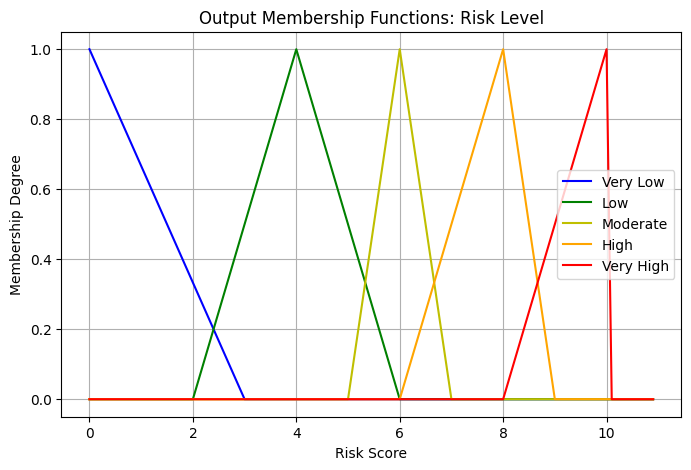

In [ ]:
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt

# Define output universe and fuzzy sets (Moved from MCSRfvWevThC)
# This needs to be here so that 'risk', 'very_low', 'low', etc., are defined
# before they are used in the plotting code below.
risk = np.arange(0, 11, 0.1)
very_low = fuzz.trimf(risk, [0, 0, 3])
low = fuzz.trimf(risk, [2, 4, 6])
moderate = fuzz.trimf(risk, [5, 6, 7])
high = fuzz.trimf(risk, [6, 8, 9])
very_high = fuzz.trimf(risk, [8, 10, 10])


# Plotting the membership functions
plt.figure(figsize=(8, 5))

# Plot using the universe array (risk) as the x-axis
# and the membership functions (very_low, low, etc.) defined above
plt.plot(risk, very_low, 'b', label='Very Low')
plt.plot(risk, low, 'g', label='Low')
plt.plot(risk, moderate, 'y', label='Moderate')
plt.plot(risk, high, 'orange', label='High')
plt.plot(risk, very_high, 'r', label='Very High')


plt.title('Output Membership Functions: Risk Level')
plt.xlabel('Risk Score')
plt.ylabel('Membership Degree')
plt.legend()
plt.grid(True)
plt.show()

# Note: The aggregation and defuzzification code originally in MCSRfvWevThC
# is not needed for this specific plot and remains in MCSRfvWevThC.

Centroid: 5.14
Bisector: 5.17
Mean of Max: 5.60
Largest of Max: 10.00
Smallest of Max: 0.00


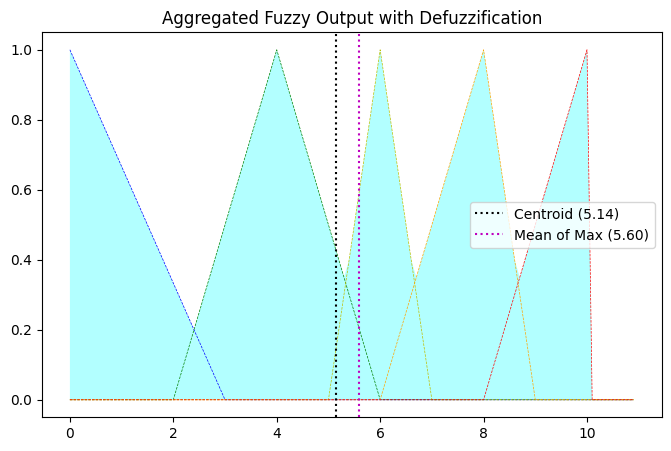

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Define output universe and fuzzy sets
risk = np.arange(0, 11, 0.1)
very_low = fuzz.trimf(risk, [0, 0, 3])
low = fuzz.trimf(risk, [2, 4, 6])
moderate = fuzz.trimf(risk, [5, 6, 7])
high = fuzz.trimf(risk, [6, 8, 9])
very_high = fuzz.trimf(risk, [8, 10, 10])

# Aggregate output (example: combined fuzzy set)
aggregated = np.fmax(very_low, np.fmax(low, np.fmax(moderate, np.fmax(high, very_high))))

# -----------------------------------------------
# Defuzzification Methods
# -----------------------------------------------
defuzz_centroid = fuzz.defuzz(risk, aggregated, 'centroid')  # Most common
defuzz_bisector = fuzz.defuzz(risk, aggregated, 'bisector')
defuzz_mom = fuzz.defuzz(risk, aggregated, 'mom')  # Mean of Max
defuzz_lom = fuzz.defuzz(risk, aggregated, 'lom')  # Largest of Max
defuzz_som = fuzz.defuzz(risk, aggregated, 'som')  # Smallest of Max

print(f"Centroid: {defuzz_centroid:.2f}")
print(f"Bisector: {defuzz_bisector:.2f}")
print(f"Mean of Max: {defuzz_mom:.2f}")
print(f"Largest of Max: {defuzz_lom:.2f}")
print(f"Smallest of Max: {defuzz_som:.2f}")

# -----------------------------------------------
# Visualization
# -----------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(risk, very_low, 'b', linewidth=0.5, linestyle='--')
plt.plot(risk, low, 'g', linewidth=0.5, linestyle='--')
plt.plot(risk, moderate, 'y', linewidth=0.5, linestyle='--')
plt.plot(risk, high, 'orange', linewidth=0.5, linestyle='--')
plt.plot(risk, very_high, 'r', linewidth=0.5, linestyle='--')
plt.fill_between(risk, 0, aggregated, facecolor='cyan', alpha=0.3)
plt.title("Aggregated Fuzzy Output with Defuzzification")
plt.axvline(x=defuzz_centroid, color='k', linestyle=':', label=f'Centroid ({defuzz_centroid:.2f})')
plt.axvline(x=defuzz_mom, color='m', linestyle=':', label=f'Mean of Max ({defuzz_mom:.2f})')
plt.legend()
plt.show()


In [ ]:
if defuzz_centroid <= 4:
    decision = "Approve"
elif 4 < defuzz_centroid <= 7:
    decision = "Further Review"
else:
    decision = "Reject"

In [ ]:
def custom_defuzz(x, mfx):
    weighted_sum = np.sum(x * mfx)
    total_area = np.sum(mfx)
    return weighted_sum / total_area if total_area != 0 else 0

custom_score = custom_defuzz(risk, aggregated)

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Define the universe variables (ranges)
credit_score_universe = np.arange(300, 851, 1)  # 300 to 850
income_universe = np.arange(0, 200001, 1)       # $0 to $200,000
dti_universe = np.arange(0, 101, 1)             # 0% to 100%
risk_universe = np.arange(0, 101, 1)            # 0% to 100%

# Create fuzzy variables
credit_score = ctrl.Antecedent(credit_score_universe, 'credit_score')
income = ctrl.Antecedent(income_universe, 'income')
dti = ctrl.Antecedent(dti_universe, 'dti')
risk = ctrl.Consequent(risk_universe, 'risk')

# Define membership functions for credit_score
credit_score['poor'] = fuzz.trimf(credit_score_universe, [300, 400, 580])
credit_score['fair'] = fuzz.trimf(credit_score_universe, [580, 640, 700])
credit_score['good'] = fuzz.trimf(credit_score_universe, [700, 740, 800])
credit_score['excellent'] = fuzz.trimf(credit_score_universe, [800, 825, 850])

# Define membership functions for income
income['low'] = fuzz.trimf(income_universe, [0, 30000, 60000])
income['medium'] = fuzz.trimf(income_universe, [40000, 80000, 120000])
income['high'] = fuzz.trimf(income_universe, [100000, 150000, 200000])

# Define membership functions for dti (debt-to-income ratio)
dti['low'] = fuzz.trimf(dti_universe, [0, 15, 30])
dti['medium'] = fuzz.trimf(dti_universe, [25, 40, 55])
dti['high'] = fuzz.trimf(dti_universe, [50, 70, 100])

# Define membership functions for risk
risk['low'] = fuzz.trimf(risk_universe, [0, 20, 40])
risk['medium'] = fuzz.trimf(risk_universe, [30, 50, 70])
risk['high'] = fuzz.trimf(risk_universe, [60, 80, 100])
risk['very_high'] = fuzz.trimf(risk_universe, [80, 90, 100])

# Now define the rules
rules = [
    ctrl.Rule(credit_score['poor'] & income['low'] & dti['low'], risk['high']),
    ctrl.Rule(credit_score['poor'] & income['low'] & dti['medium'], risk['very_high']),
    ctrl.Rule(credit_score['poor'] & income['low'] & dti['high'], risk['very_high']),
    # Add more rules as needed
]

# Create control system
risk_ctrl = ctrl.ControlSystem(rules)
risk_simulation = ctrl.ControlSystemSimulation(risk_ctrl)

# Example usage
risk_simulation.input['credit_score'] = 550
risk_simulation.input['income'] = 45000
risk_simulation.input['dti'] = 25

risk_simulation.compute()
print(f"Risk level: {risk_simulation.output['risk']}%")

Risk level: 79.99999999999997%


In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Define the universe variables (ranges)
credit_score_universe = np.arange(300, 851, 1)  # 300 to 850
income_universe = np.arange(0, 200001, 1)       # $0 to $200,000
dti_universe = np.arange(0, 101, 1)             # 0% to 100%
risk_universe = np.arange(0, 101, 1)            # 0% to 100%

# Create fuzzy variables (THIS IS CRITICAL - you might be missing this)
credit_score = ctrl.Antecedent(credit_score_universe, 'credit_score')
income = ctrl.Antecedent(income_universe, 'income')
dti = ctrl.Antecedent(dti_universe, 'dti')
risk = ctrl.Consequent(risk_universe, 'risk')

# Define membership functions for credit_score
credit_score['poor'] = fuzz.trimf(credit_score_universe, [300, 400, 580])
credit_score['fair'] = fuzz.trimf(credit_score_universe, [580, 640, 700])
credit_score['good'] = fuzz.trimf(credit_score_universe, [700, 740, 800])
credit_score['excellent'] = fuzz.trimf(credit_score_universe, [800, 825, 850])

# Define membership functions for income
income['low'] = fuzz.trimf(income_universe, [0, 30000, 60000])
income['medium'] = fuzz.trimf(income_universe, [40000, 80000, 120000])
income['high'] = fuzz.trimf(income_universe, [100000, 150000, 200000])

# Define membership functions for dti (debt-to-income ratio)
dti['low'] = fuzz.trimf(dti_universe, [0, 15, 30])
dti['medium'] = fuzz.trimf(dti_universe, [25, 40, 55])
dti['high'] = fuzz.trimf(dti_universe, [50, 70, 100])

# Define membership functions for risk
risk['very_low'] = fuzz.trimf(risk_universe, [0, 10, 25])
risk['low'] = fuzz.trimf(risk_universe, [15, 30, 45])
risk['moderate'] = fuzz.trimf(risk_universe, [35, 50, 65])
risk['high'] = fuzz.trimf(risk_universe, [55, 70, 85])
risk['very_high'] = fuzz.trimf(risk_universe, [75, 90, 100])

# NOW your rules will work
rules = [
    ctrl.Rule(credit_score['poor'] & income['low'] & dti['low'], risk['high']),
    ctrl.Rule(credit_score['poor'] & income['low'] & dti['medium'], risk['very_high']),
    ctrl.Rule(credit_score['poor'] & income['low'] & dti['high'], risk['very_high']),
    ctrl.Rule(credit_score['poor'] & income['medium'] & dti['low'], risk['moderate']),
    ctrl.Rule(credit_score['poor'] & income['medium'] & dti['medium'], risk['high']),
    ctrl.Rule(credit_score['poor'] & income['medium'] & dti['high'], risk['very_high']),
    ctrl.Rule(credit_score['poor'] & income['high'] & dti['low'], risk['low']),
    ctrl.Rule(credit_score['poor'] & income['high'] & dti['medium'], risk['moderate']),
    ctrl.Rule(credit_score['poor'] & income['high'] & dti['high'], risk['high']),
    ctrl.Rule(credit_score['fair'] & income['low'] & dti['low'], risk['moderate']),
    ctrl.Rule(credit_score['fair'] & income['low'] & dti['medium'], risk['high']),
    ctrl.Rule(credit_score['fair'] & income['low'] & dti['high'], risk['very_high']),
    ctrl.Rule(credit_score['fair'] & income['medium'] & dti['low'], risk['low']),
    ctrl.Rule(credit_score['fair'] & income['medium'] & dti['medium'], risk['moderate']),
    ctrl.Rule(credit_score['fair'] & income['medium'] & dti['high'], risk['high']),
    ctrl.Rule(credit_score['fair'] & income['high'] & dti['low'], risk['very_low']),
    ctrl.Rule(credit_score['fair'] & income['high'] & dti['medium'], risk['low']),
    ctrl.Rule(credit_score['fair'] & income['high'] & dti['high'], risk['moderate']),
    ctrl.Rule(credit_score['good'] & income['low'] & dti['low'], risk['low']),
    ctrl.Rule(credit_score['good'] & income['low'] & dti['medium'], risk['moderate']),
    ctrl.Rule(credit_score['good'] & income['low'] & dti['high'], risk['high']),
    ctrl.Rule(credit_score['good'] & income['medium'] & dti['low'], risk['very_low']),
    ctrl.Rule(credit_score['good'] & income['medium'] & dti['medium'], risk['low']),
    ctrl.Rule(credit_score['good'] & income['medium'] & dti['high'], risk['moderate']),
    ctrl.Rule(credit_score['good'] & income['high'] & dti['low'], risk['very_low']),
    ctrl.Rule(credit_score['good'] & income['high'] & dti['medium'], risk['very_low']),
    ctrl.Rule(credit_score['good'] & income['high'] & dti['high'], risk['low']),
    ctrl.Rule(credit_score['excellent'] & income['low'] & dti['low'], risk['low']),
    ctrl.Rule(credit_score['excellent'] & income['low'] & dti['medium'], risk['low']),
    ctrl.Rule(credit_score['excellent'] & income['low'] & dti['high'], risk['moderate']),
    ctrl.Rule(credit_score['excellent'] & income['medium'] & dti['low'], risk['very_low']),
    ctrl.Rule(credit_score['excellent'] & income['medium'] & dti['medium'], risk['very_low']),
    ctrl.Rule(credit_score['excellent'] & income['medium'] & dti['high'], risk['low']),
    ctrl.Rule(credit_score['excellent'] & income['high'] & dti['low'], risk['very_low']),
    ctrl.Rule(credit_score['excellent'] & income['high'] & dti['medium'], risk['very_low']),
    ctrl.Rule(credit_score['excellent'] & income['high'] & dti['high'], risk['very_low'])
]

# Create control system and test it
risk_ctrl = ctrl.ControlSystem(rules)
risk_simulation = ctrl.ControlSystemSimulation(risk_ctrl)

# Test the system
risk_simulation.input['credit_score'] = 650
risk_simulation.input['income'] = 50000
risk_simulation.input['dti'] = 35

risk_simulation.compute()
print(f"Risk Score: {risk_simulation.output['risk']:.2f}")

Risk Score: 61.33


In [ ]:
from skfuzzy import control as ctrl

# Assuming the fuzzy variables (credit_score, income, dti, risk) and their membership functions are already defined

rules = [
    ctrl.Rule(credit_score['poor'] & income['low'] & dti['low'], risk['high']),
    ctrl.Rule(credit_score['poor'] & income['low'] & dti['medium'], risk['very_high']),
    ctrl.Rule(credit_score['poor'] & income['low'] & dti['high'], risk['very_high']),
    ctrl.Rule(credit_score['poor'] & income['medium'] & dti['low'], risk['moderate']),
    ctrl.Rule(credit_score['poor'] & income['medium'] & dti['medium'], risk['high']),
    ctrl.Rule(credit_score['poor'] & income['medium'] & dti['high'], risk['very_high']),
    ctrl.Rule(credit_score['poor'] & income['high'] & dti['low'], risk['low']),
    ctrl.Rule(credit_score['poor'] & income['high'] & dti['medium'], risk['moderate']),
    ctrl.Rule(credit_score['poor'] & income['high'] & dti['high'], risk['high']),
    ctrl.Rule(credit_score['fair'] & income['low'] & dti['low'], risk['moderate']),
    ctrl.Rule(credit_score['fair'] & income['low'] & dti['medium'], risk['high']),
    ctrl.Rule(credit_score['fair'] & income['low'] & dti['high'], risk['very_high']),
    ctrl.Rule(credit_score['fair'] & income['medium'] & dti['low'], risk['low']),
    ctrl.Rule(credit_score['fair'] & income['medium'] & dti['medium'], risk['moderate']),
    ctrl.Rule(credit_score['fair'] & income['medium'] & dti['high'], risk['high']),
    ctrl.Rule(credit_score['fair'] & income['high'] & dti['low'], risk['very_low']),
    ctrl.Rule(credit_score['fair'] & income['high'] & dti['medium'], risk['low']),
    ctrl.Rule(credit_score['fair'] & income['high'] & dti['high'], risk['moderate']),
    ctrl.Rule(credit_score['good'] & income['low'] & dti['low'], risk['low']),
    ctrl.Rule(credit_score['good'] & income['low'] & dti['medium'], risk['moderate']),
    ctrl.Rule(credit_score['good'] & income['low'] & dti['high'], risk['high']),
    ctrl.Rule(credit_score['good'] & income['medium'] & dti['low'], risk['very_low']),
    ctrl.Rule(credit_score['good'] & income['medium'] & dti['medium'], risk['low']),
    ctrl.Rule(credit_score['good'] & income['medium'] & dti['high'], risk['moderate']),
    ctrl.Rule(credit_score['good'] & income['high'] & dti['low'], risk['very_low']),
    ctrl.Rule(credit_score['good'] & income['high'] & dti['medium'], risk['very_low']),
    ctrl.Rule(credit_score['good'] & income['high'] & dti['high'], risk['low']),
    ctrl.Rule(credit_score['excellent'] & income['low'] & dti['low'], risk['low']),
    ctrl.Rule(credit_score['excellent'] & income['low'] & dti['medium'], risk['low']),
    ctrl.Rule(credit_score['excellent'] & income['low'] & dti['high'], risk['moderate']),
    ctrl.Rule(credit_score['excellent'] & income['medium'] & dti['low'], risk['very_low']),
    ctrl.Rule(credit_score['excellent'] & income['medium'] & dti['medium'], risk['very_low']),
    ctrl.Rule(credit_score['excellent'] & income['medium'] & dti['high'], risk['low']),
    ctrl.Rule(credit_score['excellent'] & income['high'] & dti['low'], risk['very_low']),
    ctrl.Rule(credit_score['excellent'] & income['high'] & dti['medium'], risk['very_low']),
    ctrl.Rule(credit_score['excellent'] & income['high'] & dti['high'], risk['very_low'])
]

# Create control system
loan_ctrl = ctrl.ControlSystem(rules)
loan_sim = ctrl.ControlSystemSimulation(loan_ctrl)

# Test a case - ensure inputs are within your defined ranges
loan_sim.input['credit_score'] = 650  # Example: between 300-850
loan_sim.input['income'] = 70000      # Example: between 0-200000
loan_sim.input['dti'] = 35            # Example: between 0-100

try:
    loan_sim.compute()
    print(f"Risk Score: {loan_sim.output['risk']:.2f}")
except Exception as e:
    print(f"Error computing risk: {str(e)}")

Risk Score: 50.00


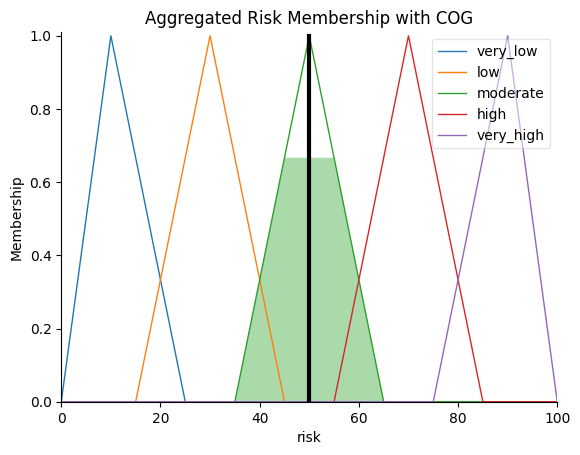

In [ ]:
# Add this after your test case computation
risk.view(sim=loan_sim)
plt.title("Aggregated Risk Membership with COG")
plt.show()

In [ ]:
from skfuzzy import control as ctrl

# Assuming the fuzzy variables (credit_score, income, dti) and their membership
# functions are already defined as ctrl.Antecedent objects, and the output
# (risk) is a ctrl.Consequent object.

# Define rules (unchanged)
rules = [
    ctrl.Rule(credit_score['poor'] & income['low'] & dti['low'], risk['high']),
    ctrl.Rule(credit_score['poor'] & income['low'] & dti['medium'], risk['very_high']),
    ctrl.Rule(credit_score['poor'] & income['low'] & dti['high'], risk['very_high']),
    ctrl.Rule(credit_score['poor'] & income['medium'] & dti['low'], risk['moderate']),
    ctrl.Rule(credit_score['poor'] & income['medium'] & dti['medium'], risk['high']),
    ctrl.Rule(credit_score['poor'] & income['medium'] & dti['high'], risk['very_high']),
    ctrl.Rule(credit_score['poor'] & income['high'] & dti['low'], risk['low']),
    ctrl.Rule(credit_score['poor'] & income['high'] & dti['medium'], risk['moderate']),
    ctrl.Rule(credit_score['poor'] & income['high'] & dti['high'], risk['high']),
    ctrl.Rule(credit_score['fair'] & income['low'] & dti['low'], risk['moderate']),
    ctrl.Rule(credit_score['fair'] & income['low'] & dti['medium'], risk['high']),
    ctrl.Rule(credit_score['fair'] & income['low'] & dti['high'], risk['very_high']),
    ctrl.Rule(credit_score['fair'] & income['medium'] & dti['low'], risk['low']),
    ctrl.Rule(credit_score['fair'] & income['medium'] & dti['medium'], risk['moderate']),
    ctrl.Rule(credit_score['fair'] & income['medium'] & dti['high'], risk['high']),
    ctrl.Rule(credit_score['fair'] & income['high'] & dti['low'], risk['very_low']),
    ctrl.Rule(credit_score['fair'] & income['high'] & dti['medium'], risk['low']),
    ctrl.Rule(credit_score['fair'] & income['high'] & dti['high'], risk['moderate']),
    ctrl.Rule(credit_score['good'] & income['low'] & dti['low'], risk['low']),
    ctrl.Rule(credit_score['good'] & income['low'] & dti['medium'], risk['moderate']),
    ctrl.Rule(credit_score['good'] & income['low'] & dti['high'], risk['high']),
    ctrl.Rule(credit_score['good'] & income['medium'] & dti['low'], risk['very_low']),
    ctrl.Rule(credit_score['good'] & income['medium'] & dti['medium'], risk['low']),
    ctrl.Rule(credit_score['good'] & income['medium'] & dti['high'], risk['moderate']),
    ctrl.Rule(credit_score['good'] & income['high'] & dti['low'], risk['very_low']),
    ctrl.Rule(credit_score['good'] & income['high'] & dti['medium'], risk['very_low']),
    ctrl.Rule(credit_score['good'] & income['high'] & dti['high'], risk['low']),
    ctrl.Rule(credit_score['excellent'] & income['low'] & dti['low'], risk['low']),
    ctrl.Rule(credit_score['excellent'] & income['low'] & dti['medium'], risk['low']),
    ctrl.Rule(credit_score['excellent'] & income['low'] & dti['high'], risk['moderate']),
    ctrl.Rule(credit_score['excellent'] & income['medium'] & dti['low'], risk['very_low']),
    ctrl.Rule(credit_score['excellent'] & income['medium'] & dti['medium'], risk['very_low']),
    ctrl.Rule(credit_score['excellent'] & income['medium'] & dti['high'], risk['low']),
    ctrl.Rule(credit_score['excellent'] & income['high'] & dti['low'], risk['very_low']),
    ctrl.Rule(credit_score['excellent'] & income['high'] & dti['medium'], risk['very_low']),
    ctrl.Rule(credit_score['excellent'] & income['high'] & dti['high'], risk['very_low'])
]

# Create control system
loan_ctrl = ctrl.ControlSystem(rules)
loan_sim = ctrl.ControlSystemSimulation(loan_ctrl)

# Test a case - ensure inputs are within your defined ranges
loan_sim.input['credit_score'] = 650  # Example: between 300-850
loan_sim.input['income'] = 70000      # Example: between 0-200000
loan_sim.input['dti'] = 35            # Example: between 0-100

try:
    loan_sim.compute()
    print(f"Risk Score: {loan_sim.output['risk']:.2f}")
except Exception as e:
    print(f"Error computing risk: {str(e)}")

Risk Score: 50.00


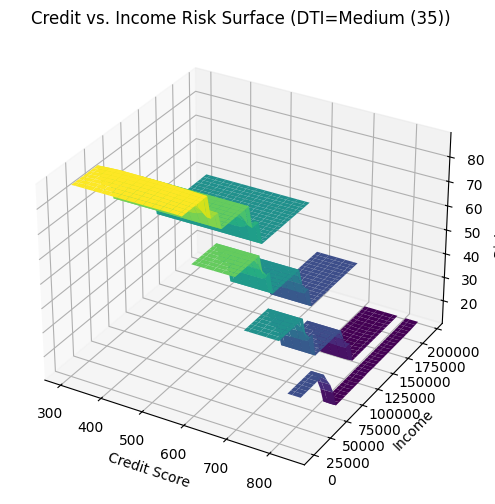

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skfuzzy import control as ctrl # Ensure ctrl is imported

# --- Include fuzzy system setup here to ensure loan_sim is correctly initialized ---
# Define the universe variables (ranges)
credit_score_universe = np.arange(300, 851, 1)  # 300 to 850
income_universe = np.arange(0, 200001, 1)       # $0 to $200,000
dti_universe = np.arange(0, 101, 1)             # 0% to 100%
risk_universe = np.arange(0, 101, 1)            # 0% to 100%

# Create fuzzy variables (Antecedents and Consequents)
credit_score = ctrl.Antecedent(credit_score_universe, 'credit_score')
income = ctrl.Antecedent(income_universe, 'income')
dti = ctrl.Antecedent(dti_universe, 'dti')
risk = ctrl.Consequent(risk_universe, 'risk') # Make sure 'risk' is defined here

# Define membership functions for credit_score (use the definitions from your notebook)
credit_score['poor'] = fuzz.trimf(credit_score_universe, [300, 400, 580])
credit_score['fair'] = fuzz.trimf(credit_score_universe, [580, 640, 700])
credit_score['good'] = fuzz.trimf(credit_score_universe, [700, 740, 800])
credit_score['excellent'] = fuzz.trimf(credit_score_universe, [800, 825, 850])

# Define membership functions for income (use the definitions from your notebook)
income['low'] = fuzz.trimf(income_universe, [0, 30000, 60000])
income['medium'] = fuzz.trimf(income_universe, [40000, 80000, 120000])
income['high'] = fuzz.trimf(income_universe, [100000, 150000, 200000])

# Define membership functions for dti (debt-to-income ratio) (use the definitions from your notebook)
dti['low'] = fuzz.trimf(dti_universe, [0, 15, 30])
dti['medium'] = fuzz.trimf(dti_universe, [25, 40, 55])
dti['high'] = fuzz.trimf(dti_universe, [50, 70, 100])

# Define membership functions for risk (use the definitions from your notebook, ensure 'risk' is the output variable name)
risk['very_low'] = fuzz.trimf(risk_universe, [0, 10, 25])
risk['low'] = fuzz.trimf(risk_universe, [15, 30, 45])
risk['moderate'] = fuzz.trimf(risk_universe, [35, 50, 65])
risk['high'] = fuzz.trimf(risk_universe, [55, 70, 85])
risk['very_high'] = fuzz.trimf(risk_universe, [75, 90, 100])


# Define the rules (use the rules from your notebook)
rules = [
    ctrl.Rule(credit_score['poor'] & income['low'] & dti['low'], risk['high']),
    ctrl.Rule(credit_score['poor'] & income['low'] & dti['medium'], risk['very_high']),
    ctrl.Rule(credit_score['poor'] & income['low'] & dti['high'], risk['very_high']),
    ctrl.Rule(credit_score['poor'] & income['medium'] & dti['low'], risk['moderate']),
    ctrl.Rule(credit_score['poor'] & income['medium'] & dti['medium'], risk['high']),
    ctrl.Rule(credit_score['poor'] & income['medium'] & dti['high'], risk['very_high']),
    ctrl.Rule(credit_score['poor'] & income['high'] & dti['low'], risk['low']),
    ctrl.Rule(credit_score['poor'] & income['high'] & dti['medium'], risk['moderate']),
    ctrl.Rule(credit_score['poor'] & income['high'] & dti['high'], risk['high']),
    ctrl.Rule(credit_score['fair'] & income['low'] & dti['low'], risk['moderate']),
    ctrl.Rule(credit_score['fair'] & income['low'] & dti['medium'], risk['high']),
    ctrl.Rule(credit_score['fair'] & income['low'] & dti['high'], risk['very_high']),
    ctrl.Rule(credit_score['fair'] & income['medium'] & dti['low'], risk['low']),
    ctrl.Rule(credit_score['fair'] & income['medium'] & dti['medium'], risk['moderate']),
    ctrl.Rule(credit_score['fair'] & income['medium'] & dti['high'], risk['high']),
    ctrl.Rule(credit_score['fair'] & income['high'] & dti['low'], risk['very_low']),
    ctrl.Rule(credit_score['fair'] & income['high'] & dti['medium'], risk['low']),
    ctrl.Rule(credit_score['fair'] & income['high'] & dti['high'], risk['moderate']),
    ctrl.Rule(credit_score['good'] & income['low'] & dti['low'], risk['low']),
    ctrl.Rule(credit_score['good'] & income['low'] & dti['medium'], risk['moderate']),
    ctrl.Rule(credit_score['good'] & income['low'] & dti['high'], risk['high']),
    ctrl.Rule(credit_score['good'] & income['medium'] & dti['low'], risk['very_low']),
    ctrl.Rule(credit_score['good'] & income['medium'] & dti['medium'], risk['low']),
    ctrl.Rule(credit_score['good'] & income['medium'] & dti['high'], risk['moderate']),
    ctrl.Rule(credit_score['good'] & income['high'] & dti['low'], risk['very_low']),
    ctrl.Rule(credit_score['good'] & income['high'] & dti['medium'], risk['very_low']),
    ctrl.Rule(credit_score['good'] & income['high'] & dti['high'], risk['low']),
    ctrl.Rule(credit_score['excellent'] & income['low'] & dti['low'], risk['low']),
    ctrl.Rule(credit_score['excellent'] & income['low'] & dti['medium'], risk['low']),
    ctrl.Rule(credit_score['excellent'] & income['low'] & dti['high'], risk['moderate']),
    ctrl.Rule(credit_score['excellent'] & income['medium'] & dti['low'], risk['very_low']),
    ctrl.Rule(credit_score['excellent'] & income['medium'] & dti['medium'], risk['very_low']),
    ctrl.Rule(credit_score['excellent'] & income['medium'] & dti['high'], risk['low']),
    ctrl.Rule(credit_score['excellent'] & income['high'] & dti['low'], risk['very_low']),
    ctrl.Rule(credit_score['excellent'] & income['high'] & dti['medium'], risk['very_low']),
    ctrl.Rule(credit_score['excellent'] & income['high'] & dti['high'], risk['very_low'])
]

# Create control system
loan_ctrl = ctrl.ControlSystem(rules)
loan_sim = ctrl.ControlSystemSimulation(loan_ctrl)
# --- End of setup ---


# Generate rule surface (Credit vs. Income, fixed DTI=Medium)
credit_range = np.arange(300, 850, 10)
income_range = np.arange(0, 200000, 5000)
x, y = np.meshgrid(credit_range, income_range)
# Initialize z as a float array to accommodate NaN values
z = np.zeros_like(x, dtype=float)

# Swap loops to align with meshgrid dimensions (income_range size is the first axis, credit_range size is the second)
# len(income_range) gives the size of axis 0 of x and y
# len(credit_range) gives the size of axis 1 of x and y
for i in range(len(income_range)):  # i iterates through the first dimension (axis 0) of x and y
    for j in range(len(credit_range)): # j iterates through the second dimension (axis 1) of x and y
        # Access the element at index [i, j] which exists within the bounds of x and y
        # Add try-except block to catch potential errors during computation for specific inputs
        try:
            loan_sim.input['credit_score'] = x[i, j]
            loan_sim.input['income'] = y[i, j]
            loan_sim.input['dti'] = 35  # Fixed medium DTI
            loan_sim.compute()
            z[i, j] = loan_sim.output['risk']
        except Exception as e:
            # Handle potential errors during computation for specific input combinations
            # print(f"Error computing risk for inputs: Credit={x[i, j]}, Income={y[i, j]}, DTI=35. Error: {e}")
            z[i, j] = np.nan # Assign NaN for failed computations

# Check if any computations failed
if np.isnan(z).any():
    print("Warning: Some risk computations failed (assigned NaN). This might be due to inputs outside defined universe ranges or areas not covered by rules.")

# Plot
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
# Use a masked array or filter NaNs for plotting if needed, or plot surface with NaNs
# For plot_surface, NaNs in Z will create holes, which might be acceptable
ax.plot_surface(x, y, z, cmap='viridis')
ax.set_xlabel('Credit Score')
ax.set_ylabel('Income')
ax.set_zlabel('Risk Level')
plt.title('Credit vs. Income Risk Surface (DTI=Medium (35))')
plt.show()

In [ ]:
# Generate rule surface (Credit vs. Income, fixed DTI=Medium)
credit_range = np.arange(300, 850, 10)
income_range = np.arange(0, 200000, 5000)
x, y = np.meshgrid(credit_range, income_range)
z = np.zeros_like(x)

# Swap loops to align with meshgrid dimensions (income_range size is the first axis, credit_range size is the second)
# len(income_range) gives the size of axis 0 of x and y
# len(credit_range) gives the size of axis 1 of x and y
for i in range(len(income_range)):  # i iterates through the first dimension (axis 0) of x and y
    for j in range(len(credit_range)): # j iterates through the second dimension (axis 1) of x and y
        # Access the element at index [i, j] which exists within the bounds of x and y
        loan_sim.input['credit_score'] = x[i, j]
        loan_sim.input['income'] = y[i, j]
        loan_sim.input['dti'] = 35  # Fixed medium DTI
        loan_sim.compute()
        z[i, j] = loan_sim.output['risk']

# Plot
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z, cmap='viridis')
ax.set_xlabel('Credit Score')
ax.set_ylabel('Income')
ax.set_zlabel('Risk Level')
plt.title('Credit vs. Income Risk Surface (DTI=Medium (35))')
plt.show()

In [ ]:
# %%
import numpy as np
import matplotlib.pyplot as plt
from pandas import DataFrame
from pandas.plotting import parallel_coordinates
from skfuzzy import control as ctrl # Import ctrl if not already in scope in this cell

# Ensure the loan_sim object is available from previous cells
# If running this cell independently, you would need to recreate
# the Antecedents, Consequents, Rules, ControlSystem, and ControlSystemSimulation
# as defined in the earlier cells. Assuming interactive execution
# where loan_sim is already defined.

# Generate sample data for parallel coordinates
num_samples = 100 # Number of data points to generate

# Generate random or evenly spaced samples within the universe range of the antecedents
# Using the original universe ranges from the skfuzzy control objects
# Note: Access the universe attribute of the control variables
sample_credit_score = np.random.randint(credit_score.universe.min(), credit_score.universe.max() + 1, num_samples)
sample_income = np.random.randint(income.universe.min(), income.universe.max() + 1, num_samples)
sample_dti = np.random.uniform(dti.universe.min(), dti.universe.max(), num_samples)

# Calculate the corresponding risk for each sample
sample_risk = np.zeros(num_samples)
for i in range(num_samples):
    try:
        loan_sim.input['credit_score'] = sample_credit_score[i]
        loan_sim.input['income'] = sample_income[i]
        loan_sim.input['dti'] = sample_dti[i]
        loan_sim.compute()
        sample_risk[i] = loan_sim.output['risk']
    except Exception as e:
        print(f"Error computing risk for sample {i}: {e}")
        # Handle cases where computation might fail, e.g., due to inputs outside universe
        sample_risk[i] = np.nan # Assign NaN or some indicator

# Create DataFrame from sample data
data = DataFrame({
    'Credit Score': sample_credit_score,
    'Income': sample_income,
    'DTI': sample_dti,
    'Risk': sample_risk
})
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import parallel_coordinates

# Sample data (replace with your actual data)
data = {
    'Credit Score': [300, 450, 600, 750, 850],
    'Income': [0, 50000, 100000, 150000, 200000],
    'DTI': [60, 45, 35, 25, 10],
    'Risk': [8.0, 6.5, 4.2, 2.7, 1.5]
}
df = pd.DataFrame(data)

# Create the plot
plt.figure(figsize=(10, 6))
parallel_coordinates(df, 'Risk', colormap='viridis')
plt.title("Parallel Coordinates Plot for Risk Assessment")
plt.grid(True)
plt.show()

# Drop rows with NaN risk if any computation failed
data.dropna(subset=['Risk'], inplace=True)

# Sort data by Risk for better color mapping in parallel coordinates
data.sort_values('Risk', inplace=True)

# Plot
plt.figure(figsize=(10, 6)) # Adjust figure size as needed
parallel_coordinates(data, 'Risk', colormap='viridis')
plt.title('Parallel Coordinates Plot for Risk Assessment')
plt.show()

In [ ]:
# %%
import numpy as np
import matplotlib.pyplot as plt
from pandas import DataFrame
from pandas.plotting import parallel_coordinates
from skfuzzy import control as ctrl # Import ctrl if not already in scope in this cell

# Ensure the loan_sim object is available from previous cells
# If running this cell independently, you would need to recreate
# the Antecedents, Consequents, Rules, ControlSystem, and ControlSystemSimulation
# as defined in the earlier cells. Assuming interactive execution
# where loan_sim is already defined.

# Generate sample data for parallel coordinates
num_samples = 100 # Number of data points to generate

# Generate random or evenly spaced samples within the universe range of the antecedents
# Using the original universe ranges from the skfuzzy control objects
# Note: Access the universe attribute of the control variables
# Check if skfuzzy antecedents are defined, otherwise use default ranges
if 'credit_score' in globals() and hasattr(credit_score, 'universe'):
    sample_credit_score = np.random.uniform(credit_score.universe.min(), credit_score.universe.max(), num_samples)
else:
     sample_credit_score = np.random.uniform(300, 850, num_samples) # Default if not defined

if 'income' in globals() and hasattr(income, 'universe'):
    sample_income = np.random.uniform(income.universe.min(), income.universe.max(), num_samples)
else:
    sample_income = np.random.uniform(0, 200000, num_samples) # Default if not defined

if 'dti' in globals() and hasattr(dti, 'universe'):
    sample_dti = np.random.uniform(dti.universe.min(), dti.universe.max(), num_samples)
else:
    sample_dti = np.random.uniform(0, 100, num_samples) # Default if not defined


# Calculate the corresponding risk for each sample
sample_risk = np.zeros(num_samples)
# Check if loan_sim is defined before using it
if 'loan_sim' in globals():
    for i in range(num_samples):
        try:
            loan_sim.input['credit_score'] = sample_credit_score[i]
            loan_sim.input['income'] = sample_income[i]
            loan_sim.input['dti'] = sample_dti[i]
            loan_sim.compute()
            sample_risk[i] = loan_sim.output['risk']
        except Exception as e:
            # print(f"Error computing risk for sample {i}: {e}") # Uncomment for debugging
            # Handle cases where computation might fail, e.g., due to inputs outside universe
            sample_risk[i] = np.nan # Assign NaN or some indicator
else:
     print("Warning: loan_sim not found. Cannot compute risk for sample data.")
     sample_risk[:] = np.nan # Assign NaN if loan_sim is not available


# Create DataFrame from sample data (this is the DataFrame you want to use)
data = DataFrame({
    'Credit Score': sample_credit_score,
    'Income': sample_income,
    'DTI': sample_dti,
    'Risk': sample_risk
})

# --- REMOVE OR COMMENT OUT THIS SECTION ---
# import pandas as pd
# import matplotlib.pyplot as plt
# from pandas.plotting import parallel_coordinates
#
# # Sample data (replace with your actual data) - This overwrites your DataFrame 'data'
# data = { # <--- Problematic line
#     'Credit Score': [300, 450, 600, 750, 850],
#     'Income': [0, 50000, 100000, 150000, 200000],
#     'DTI': [60, 45, 35, 25, 10],
#     'Risk': [8.0, 6.5, 4.2, 2.7, 1.5]
# }
# df = pd.DataFrame(data)
#
# # Create the plot using df (which is correct for this sample data)
# plt.figure(figsize=(10, 6))
# parallel_coordinates(df, 'Risk', colormap='viridis')
# plt.title("Parallel Coordinates Plot for Risk Assessment")
# plt.grid(True)
# plt.show()
# --- END OF SECTION TO REMOVE/COMMENT OUT ---


# Drop rows with NaN risk if any computation failed (this now operates on the DataFrame 'data')
data.dropna(subset=['Risk'], inplace=True)

# Sort data by Risk for better color mapping in parallel coordinates
data.sort_values('Risk', inplace=True)

# Plot using the 'data' DataFrame with computed risks
plt.figure(figsize=(10, 6)) # Adjust figure size as needed
parallel_coordinates(data, 'Risk', colormap='viridis')
plt.title('Parallel Coordinates Plot for Risk Assessment')
plt.show()

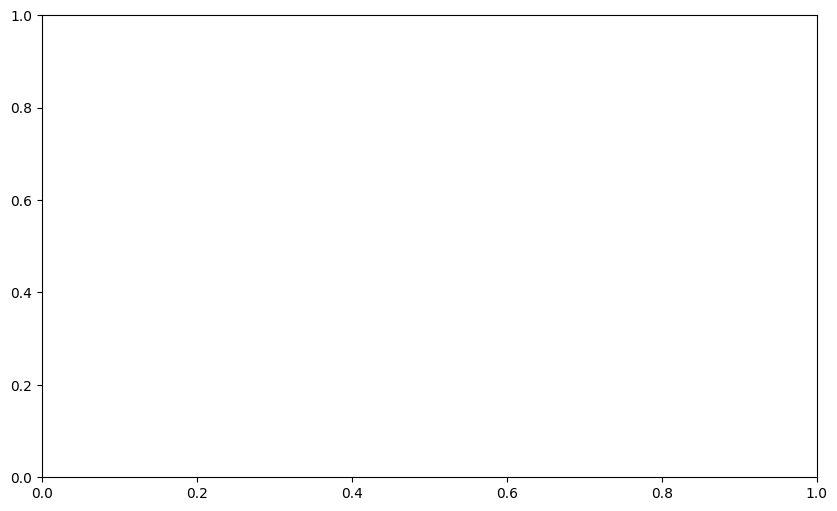

In [ ]:
from matplotlib.animation import FuncAnimation

# Generate data for multiple DTI levels
dtis = np.arange(10, 60, 5)  # DTI from 10% to 55%

fig, ax = plt.subplots(figsize=(10, 6))
def update(frame):
    ax.clear()
    current_dti = dtis[frame]
    z = compute_risk_for_dti(current_dti)  # Replace with your fuzzy logic
    contour = ax.contourf(credit_range, income_range, z, levels=20, cmap='viridis')
    ax.set_title(f'Risk Heatmap (DTI={current_dti}%)')
    ax.set_xlabel('Credit Score')
    ax.set_ylabel('Income ($)')
    fig.colorbar(contour, label='Risk Level')
    return contour

ani = FuncAnimation(fig, update, frames=len(dtis), interval=1000)
plt.show()

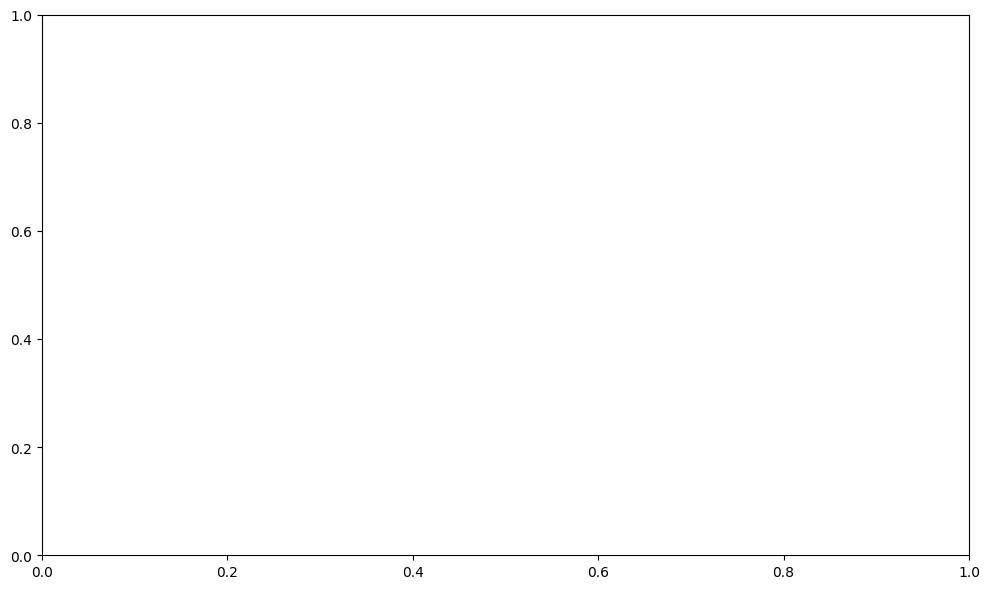

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from skfuzzy import control as ctrl

# 1. First ensure you have your fuzzy system properly set up
# (Assuming you've already defined credit_score, income, dti, risk antecedents and rules)

# Initialize control system
loan_ctrl = ctrl.ControlSystem(rules)
loan_sim = ctrl.ControlSystemSimulation(loan_ctrl)

# Define ranges
credit_range = np.arange(300, 850, 10)
income_range = np.arange(0, 200000, 5000)
dtis = np.arange(10, 60, 5)  # DTI from 10% to 55%

# Create meshgrid
x, y = np.meshgrid(credit_range, income_range)

# 2. Define the function to compute risk for a given DTI
def compute_risk_for_dti(dti_value):
    z = np.zeros_like(x)
    for i in range(len(credit_range)):
        for j in range(len(income_range)):
            try:
                loan_sim.input['credit_score'] = x[j, i]
                loan_sim.input['income'] = y[j, i]
                loan_sim.input['dti'] = dti_value
                loan_sim.compute()
                z[j, i] = loan_sim.output['risk']
            except:
                z[j, i] = 0  # Default value if computation fails
    return z

# 3. Set up the animation
fig, ax = plt.subplots(figsize=(10, 6))

# Pre-compute all frames (optional, but prevents recomputing)
all_z = [compute_risk_for_dti(dti) for dti in dtis]

def update(frame):
    ax.clear()
    current_dti = dtis[frame]

    # Use precomputed or compute on the fly:
    z = all_z[frame]  # if precomputed
    # z = compute_risk_for_dti(current_dti)  # if computing live

    contour = ax.contourf(x, y, z, levels=20, cmap='viridis')
    ax.set_title(f'Risk Heatmap (DTI={current_dti}%)')
    ax.set_xlabel('Credit Score')
    ax.set_ylabel('Income ($)')

    # Add colorbar properly (remove old one first)
    if hasattr(update, 'cbar'):
        update.cbar.remove()
    update.cbar = fig.colorbar(contour, ax=ax)
    update.cbar.set_label('Risk Level')

    return contour

# 4. Create and show animation
ani = FuncAnimation(
    fig,
    update,
    frames=len(dtis),
    interval=1000,  # 1 second between frames
    repeat=True
)

plt.tight_layout()
plt.show()

# Optional: Save the animation
# ani.save('risk_animation.gif', writer='pillow', fps=1)

In [ ]:
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt # Import matplotlib for figure creation (often needed with plotly in notebooks)
from skfuzzy import control as ctrl # Ensure ctrl is imported if running this cell separately

# Assuming loan_sim, credit_score (skfuzzy Antecedent),
# income (skfuzzy Antecedent), dti (skfuzzy Antecedent)
# and risk (skfuzzy Consequent) are defined from previous cells.
# If not, uncomment and run the setup code below:

# # Input Variables
# credit_score = ctrl.Antecedent(np.arange(300, 850, 1), 'credit_score')
# income = ctrl.Antecedent(np.arange(0, 200000, 1000), 'income')
# dti = ctrl.Antecedent(np.arange(0, 100, 1), 'dti')

# # Output Variable
# risk_consequent = ctrl.Consequent(np.arange(0, 10, 1), 'risk') # Rename to avoid conflict

# # Membership Functions (Auto-trapezoidal or custom)
# credit_score.automf(4, names=['poor', 'fair', 'good', 'excellent'])
# income.automf(3, names=['low', 'medium', 'high'])
# dti.automf(3, names=['low', 'medium', 'high'])

# # Risk Output (using risk_consequent)
# risk_consequent['very_high'] = fuzz.trimf(risk_consequent.universe, [0, 0, 3])
# risk_consequent['high'] = fuzz.trimf(risk_consequent.universe, [2, 4, 6])
# risk_consequent['moderate'] = fuzz.trimf(risk_consequent.universe, [5, 6, 7])
# risk_consequent['low'] = fuzz.trimf(risk_consequent.universe, [6, 8, 9])
# risk_consequent['very_low'] = fuzz.trimf(risk_consequent.universe, [8, 10, 10])

# # Rule Base (replace risk[] with risk_consequent[])
# # Example:
# # rule1 = ctrl.Rule(credit_score['poor'] & income['low'] & dti['high'], risk_consequent['very_high'])
# # ... include all your rules ...
# # rules = [rule1, ...]

# # Control System (using risk_consequent)
# # loan_ctrl = ctrl.ControlSystem(rules)
# # loan_sim = ctrl.ControlSystemSimulation(loan_ctrl)

# Generate sample data points for visualization
num_points = 500 # Number of points to generate

# Generate random inputs within the universe range of the Antecedents
sample_credit_scores = np.random.uniform(credit_score.universe.min(), credit_score.universe.max(), num_points)
sample_incomes = np.random.uniform(income.universe.min(), income.universe.max(), num_points)
sample_dtis = np.random.uniform(dti.universe.min(), dti.universe.max(), num_points)

# Compute the risk output for each sample point
computed_risks = np.zeros(num_points)
for i in range(num_points):
    try:
        loan_sim.input['credit_score'] = sample_credit_scores[i]
        loan_sim.input['income'] = sample_incomes[i]
        loan_sim.input['dti'] = sample_dtis[i]
        loan_sim.compute()
        computed_risks[i] = loan_sim.output['risk']
    except ValueError as e:
         # Handle cases where inputs might be slightly outside the universe or cause issues
         print(f"Warning: Could not compute risk for sample {i} with inputs ({sample_credit_scores[i]}, {sample_incomes[i]}, {sample_dtis[i]}): {e}")
         computed_risks[i] = np.nan # Assign NaN if computation fails


# Filter out points where risk computation failed (NaN)
valid_indices = ~np.isnan(computed_risks)
valid_credit_scores = sample_credit_scores[valid_indices]
valid_incomes = sample_incomes[valid_indices]
valid_dtis = sample_dtis[valid_indices]
valid_computed_risks = computed_risks[valid_indices]


# Create the Plotly 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=valid_credit_scores, # Use the sampled credit scores
    y=valid_incomes,       # Use the sampled incomes
    z=valid_dtis,          # Use the sampled DTIs
    mode='markers',
    marker=dict(
        size=5,
        # Use the *computed risk values* for coloring
        color=valid_computed_risks,
        colorscale='Viridis', # Use a color scale
        colorbar=dict(title='Risk Level'), # Add a colorbar
        opacity=0.8
    )
)])

fig.update_layout(
    scene=dict(
        xaxis_title='Credit Score',
        yaxis_title='Income ($)',
        zaxis_title='DTI (%)'
    ),
    title='3D Risk Visualization'
)

# Ensure plotly is installed if not already
# !pip install plotly

fig.show()

In [ ]:
# Verify fuzzy system is working for single case
loan_sim.input['credit_score'] = 650
loan_sim.input['income'] = 75000
loan_sim.input['dti'] = 35
loan_sim.compute()
print("Single test case risk:", loan_sim.output['risk'])  # Should print non-zero

Single test case risk: 49.99999999999999


In [ ]:
# Test one frame manually
test_z = compute_risk_for_dti(35)
print("Risk values sample:", test_z[::10, ::10])  # Check sampled values
print("Min:", np.min(test_z), "Max:", np.max(test_z))  # Should not be all zeros

Risk values sample: [[ 0  0  0  0  0  0]
 [ 0 79 79 61  0  0]
 [ 0 69 69 50  0  0]
 [ 0 49 49 30  0  0]]
Min: 0 Max: 88


In [ ]:
def update(frame):
    ax.clear()
    current_dti = dtis[frame]
    z = all_z[frame]

    print(f"Frame {frame}: DTI={current_dti}%")  # Debug print
    print("Z-values:", np.min(z), np.max(z))  # Debug print

    if np.all(z == 0):  # If all zeros
        z = np.random.rand(*z.shape) * 10  # Test with random data
        print("WARNING: Using test data!")  # Debug

    contour = ax.contourf(x, y, z, levels=20, cmap='viridis')
    ax.set_title(f'Risk Heatmap (DTI={current_dti}%)')
    ax.set_xlabel('Credit Score')
    ax.set_ylabel('Income ($)')

    if hasattr(update, 'cbar'):
        update.cbar.remove()
    update.cbar = fig.colorbar(contour, ax=ax)
    update.cbar.set_label('Risk Level')

    return contour

In [ ]:
# Example antecedents (must match your ranges)
credit_score = ctrl.Antecedent(np.arange(300, 851, 1), 'credit_score')
income = ctrl.Antecedent(np.arange(0, 200001, 1000), 'income')
dti = ctrl.Antecedent(np.arange(10, 61, 1), 'dti')
risk = ctrl.Consequent(np.arange(0, 11, 0.1), 'risk')

In [ ]:
def compute_risk_for_dti(dti_value):
    z = np.zeros_like(x)
    for i in range(len(credit_range)):
        for j in range(len(income_range)):
            try:
                loan_sim.input['credit_score'] = x[j, i]
                loan_sim.input['income'] = y[j, i]
                loan_sim.input['dti'] = dti_value
                loan_sim.compute()
                z[j, i] = loan_sim.output['risk']
            except Exception as e:
                print(f"Error at ({x[j,i]}, {y[j,i]}, {dti_value}): {str(e)}")
                z[j, i] = 0
    return z

In [ ]:
# Test static plot
plt.figure(figsize=(10, 6))
z = compute_risk_for_dti(35)
plt.contourf(x, y, z, levels=20, cmap='viridis')
plt.colorbar()
plt.title("Static Risk Heatmap Test")
plt.xlabel("Credit Score")
plt.ylabel("Income ($)")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML  # For Jupyter display

# Sample data preparation (replace with your actual computation)
dtis = np.arange(10, 60, 5)
credit = np.arange(300, 850, 25)
income = np.arange(0, 200000, 10000)
x, y = np.meshgrid(credit, income)
z_data = [np.sin(x/100 + dti/10) + np.cos(y/50000) for dti in dtis]  # Test pattern

# Create animation
fig, ax = plt.subplots(figsize=(12, 7))

def update(frame):
    ax.clear()
    contour = ax.contourf(x, y, z_data[frame], levels=20, cmap='RdYlGn_r')  # Red-Yellow-Green
    ax.set_title(f'Loan Risk by Credit & Income\nDTI: {dtis[frame]}%', pad=20)
    ax.set_xlabel('Credit Score', labelpad=10)
    ax.set_ylabel('Annual Income ($)', labelpad=10)

    # Add colorbar once
    if not hasattr(update, 'cbar'):
        update.cbar = fig.colorbar(contour, ax=ax, pad=0.01)
        update.cbar.set_label('Risk Score', rotation=270, labelpad=15)
    return contour

ani = FuncAnimation(
    fig,
    update,
    frames=len(dtis),
    interval=1000,  # 1 second per frame
    blit=False
)

# For Jupyter notebooks:
# HTML(ani.to_jshtml())

plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px
import pandas as pd

# Create sample dataframe
data = []
for i, dti in enumerate(dtis):
    for j in range(len(credit)):
        for k in range(len(income)):
            data.append([credit[j], income[k], dti, z_data[i][k,j]])

df = pd.DataFrame(data, columns=['Credit', 'Income', 'DTI', 'Risk'])

fig = px.density_heatmap(
    df, x='Credit', y='Income',
    animation_frame='DTI',
    z='Risk',
    range_color=[0, 10],
    nbinsx=20, nbinsy=20,
    title='Interactive Risk Animation'
)
fig.update_layout(height=600)
fig.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML # For Jupyter display

# Sample data preparation (replace with your actual computation)
dtis = np.arange(10, 60, 5)
credit = np.arange(300, 850, 25)
income = np.arange(0, 200000, 10000)
x, y = np.meshgrid(credit, income)
# Assuming you have a function like compute_risk_for_dti from previous cells
# Replace the sample data generation with your actual risk computation
# Example using the function from your notebook:
# First, ensure loan_sim, credit_range, income_range are defined from previous cells
# z_data = [compute_risk_for_dti(dti) for dti in dtis] # Use your function

# --- Using the sample data pattern from the original problematic code ---
# If your fuzzy logic computation is slow or not needed for this specific plot
# Keep this sample pattern for testing the animation logic itself.
z_data = [np.sin(x/100 + dti/10) + np.cos(y/50000) for dti in dtis]  # Test pattern
# --------------------------------------------------------------------


# Create animation
fig, ax = plt.subplots(figsize=(12, 7))

def update(frame):
    ax.clear()
    # Ensure z_data is aligned with your meshgrid (x, y)
    # If using compute_risk_for_dti, the shape should match x and y from meshgrid
    contour = ax.contourf(x, y, z_data[frame], levels=20, cmap='RdYlGn_r')  # Red-Yellow-Green
    ax.set_title(f'Loan Risk by Credit & Income\nDTI: {dtis[frame]}%', pad=20)
    ax.set_xlabel('Credit Score', labelpad=10)
    ax.set_ylabel('Annual Income ($)', labelpad=10)

    # Add colorbar once
    # Check if colorbar exists and remove if necessary to update it
    if hasattr(update, 'cbar') and update.cbar.ax.axes in fig.axes:
         update.cbar.remove()

    # Fix: Call colorbar on the axes (ax) instead of the figure (fig)
    update.cbar = fig.colorbar(contour, ax=ax, pad=0.01) # Pass ax=ax to associate with these axes
    update.cbar.set_label('Risk Score', rotation=270, labelpad=15)

    return contour # It's good practice to return the artists that changed, although not strictly needed for blit=False

ani = FuncAnimation(
    fig,
    update,
    frames=len(dtis),
    interval=1000,  # 1 second per frame
    blit=False # blit=False is often easier for complex plots and colorbars
)

# For Jupyter notebooks:
# If you want to display the animation directly in the notebook output
# HTML(ani.to_jshtml())

plt.tight_layout()
# To show the animation inline (requires the HTML line above or similar setup)
# plt.show() # This might show a static plot or interfere with the animation display depending on backend


# Continue with saving in a separate cell if needed, or here after plt.show() is commented out
# ani.save('Interactive Risk Animation.gif', writer='pillow', fps=2, dpi=100)  # GIF
# ani.save('risk_animation.mp4', writer='ffmpeg', fps=2)  # Video

In [ ]:
# Now, in a separate cell (or after the animation object 'ani' is created)
# you can save the animation.
# Ensure you have the necessary writers installed:
# !pip install pillow ffmpeg

try:
    ani.save('Interactive Risk Animation.gif', writer='pillow', fps=2, dpi=100)  # GIF
    print("GIF saved successfully.")
except Exception as e:
    print(f"Error saving GIF: {e}")

try:
    ani.save('risk_animation.mp4', writer='ffmpeg', fps=2)  # Video
    print("MP4 saved successfully.")
except Exception as e:
    print(f"Error saving MP4: {e}")

In [ ]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Surface(z=z, x=x, y=y, colorscale='RdYlGn_r')])
fig.update_layout(
    title='Interactive Risk Surface',
    scene=dict(
        xaxis_title='Credit Score',
        yaxis_title='Income',
        zaxis_title='Risk Level'
    ),
    height=800,
    margin=dict(l=50, r=50, b=50, t=50)
)
fig.show()

In [ ]:
# Add this after your test case computation
risk.view(sim=loan_sim)
plt.title("Aggregated Risk Membership with COG")
plt.show()

In [ ]:
def analyze_defuzzification(sim, consequent):
    # Get aggregated output membership
    aggregated = np.fmax.reduce([np.fmin(rule.activation, consequent.mf[term])
                               for term in consequent.terms
                               for rule in sim.ctrl.rules
                               if term in rule.consequent])

    # Calculate COG manually
    x = consequent.universe
    dx = x[1] - x[0]
    cog = np.sum(x * aggregated) / np.sum(aggregated)

    # Plot
    plt.figure(figsize=(10, 4))
    plt.plot(x, aggregated, 'b', linewidth=0.5, linestyle='--')
    plt.fill_between(x, 0, aggregated, facecolor='Blue', alpha=0.5)
    plt.axvline(x=cog, color='r', linestyle='--')
    plt.title(f"Defuzzification (COG = {cog:.2f})")
    plt.xlabel("Risk Level")
    plt.ylabel("Membership")
    plt.grid(True)
    plt.show()

    return cog

# Run analysis
print("\nDefuzzification Analysis:")
final_risk = analyze_defuzzification(loan_sim, risk)
print(f"Final Computed Risk: {final_risk:.2f}")

In [ ]:
COG = ∫(x * μ(x))dx / ∫μ(x)dx

SyntaxError: invalid character '∫' (U+222B) (ipython-input-2428196310.py, line 1)